In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/sample_data/project.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
import pandas as pd
missing_counts = df.isna().sum()
print("Missing values per column:", missing_counts)
print("Total missing cells:", df.isna().sum().sum())


Missing values per column: customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Total missing cells: 0


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [6]:
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

In [8]:
df = df.drop(columns=['customerID'])
df = df.drop_duplicates()

print(df.isna().sum())
print(df.isna().sum().sum())
print(df.duplicated().sum())
print(df.shape)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Numeric       0
dtype: int64
0
0
(7021, 21)


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_Numeric
count,7021.000000,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2288.954490,0.264492
std,0.368947,24.534965,30.069001,2265.319449,0.441094
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.750000,411.150000,0.000000
50%,0.000000,29.000000,70.400000,1400.550000,0.000000
75%,0.000000,55.000000,89.900000,3801.700000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [10]:
q1 = df['MonthlyCharges'].quantile(0.25)
q3 = df['MonthlyCharges'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers = df[
    (df['MonthlyCharges'] < lower_bound) | (df['MonthlyCharges'] > upper_bound)
]
print(len(outliers))

0


In [11]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
print("Final shape of cleaned dataset:", df.shape)
print("\nMissing values remaining:")
print(df.isna().sum())
print("\nDuplicate rows remaining:", df.duplicated().sum())
df.head(10)

Final shape of cleaned dataset: (7021, 21)

Missing values remaining:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Churn_Numeric       0
dtype: int64

Duplicate rows remaining: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,0


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('/content/sample_data/project.csv')

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  df[col] = df[col].astype(str).str.strip()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

df = df.drop(columns=['customerID'])
df = df.drop_duplicates()

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


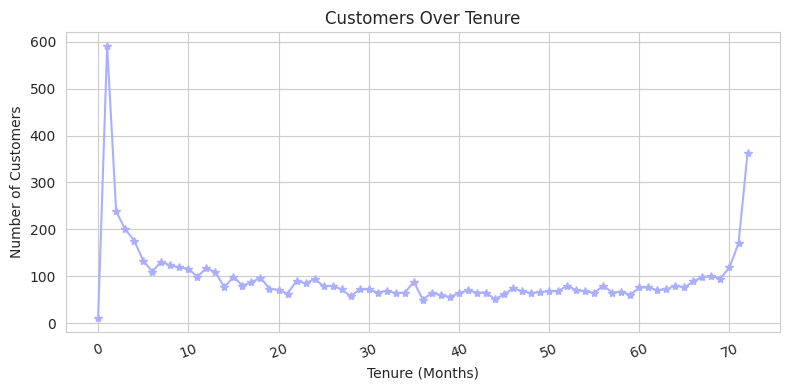

In [14]:
tenure_counts = df['tenure'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.plot(tenure_counts.index, tenure_counts.values, color='#aaafff', marker='*')
plt.title('Customers Over Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

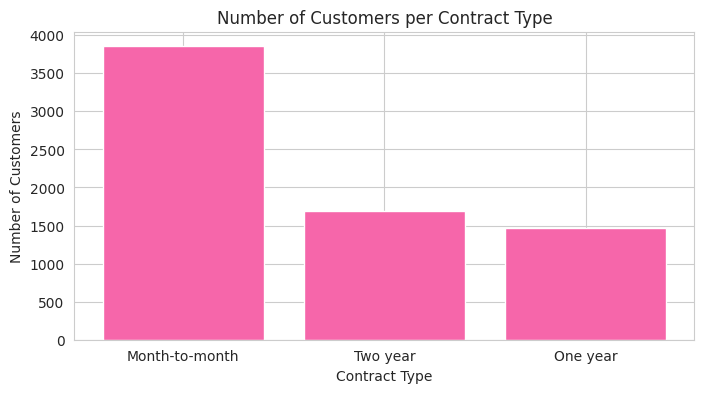

In [15]:
contract_counts = df['Contract'].value_counts()

plt.figure(figsize=(8,4))
plt.bar(contract_counts.index, contract_counts.values, color='#f666aa')
plt.title('Number of Customers per Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

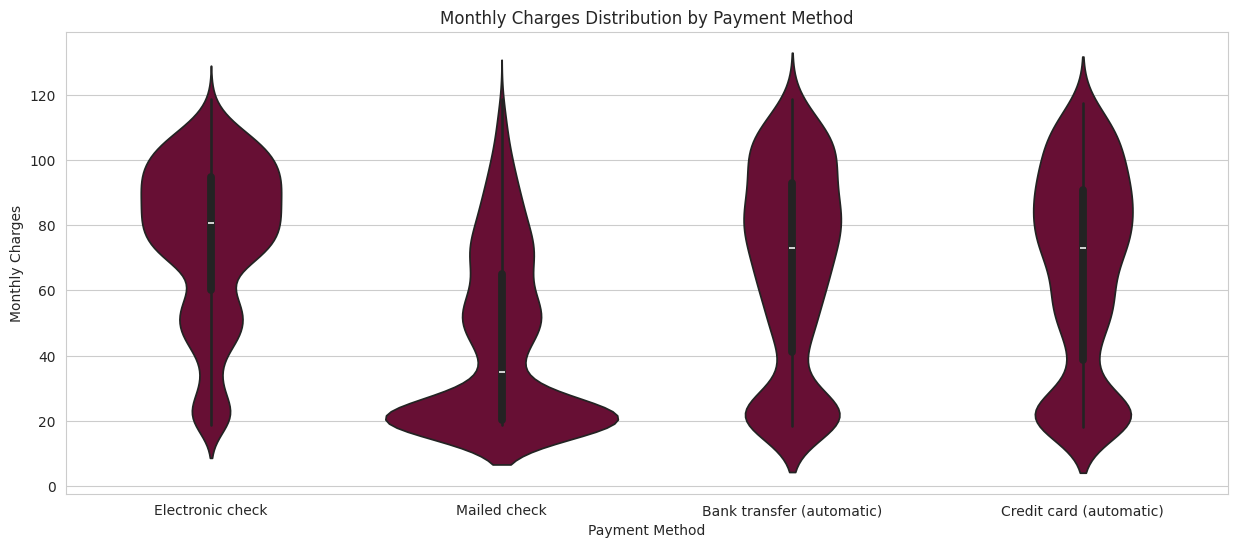

In [16]:
plt.figure(figsize=(15,6))
sns.violinplot(x='PaymentMethod', y='MonthlyCharges', data=df, color='#760031')
plt.title('Monthly Charges Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Monthly Charges')
plt.show()

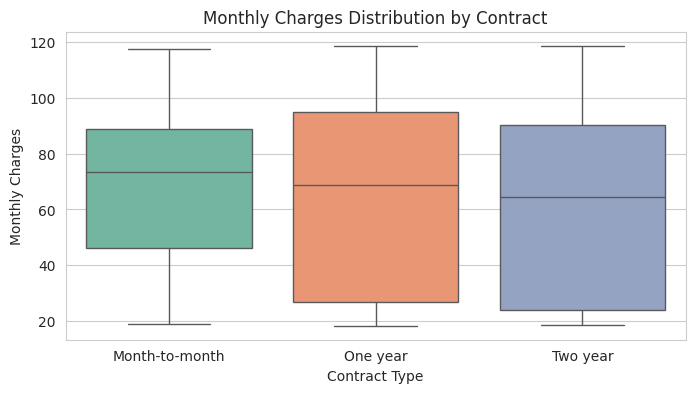

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Contract', y='MonthlyCharges', data=df, hue='Contract', palette='Set2', legend=False)
plt.title('Monthly Charges Distribution by Contract')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.show()

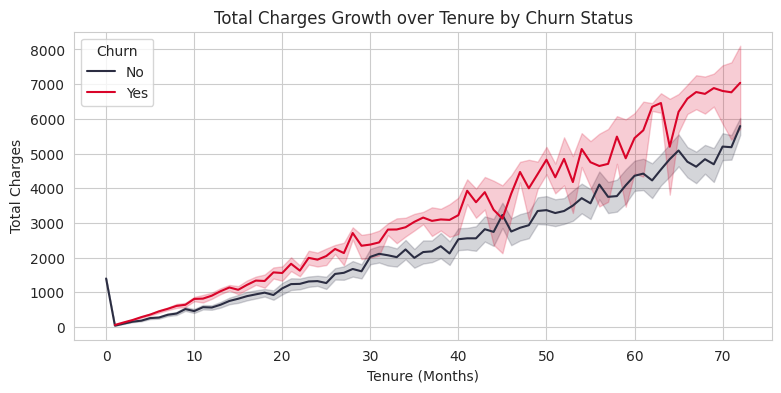

In [18]:
plt.figure(figsize=(9, 4))
sns.lineplot(x='tenure', y='TotalCharges', hue='Churn', data=df, palette=['#2b2d42', '#d90429'])
plt.title('Total Charges Growth over Tenure by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges')
plt.show()

In [19]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean().round(3)* 100))
print(contract_churn_rate )

Contract
Month-to-month    42.6
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


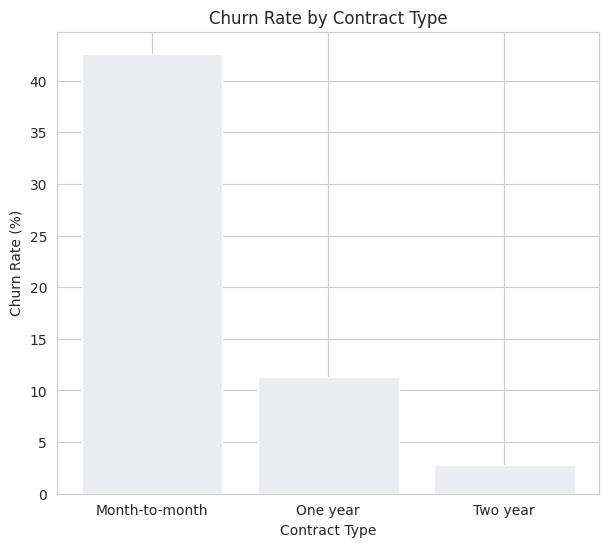

In [20]:
plt.figure(figsize=(7,6))
plt.bar(contract_churn_rate.index,contract_churn_rate.values,color="#EAECEF")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

In [21]:
tech_support_churn = (df.groupby("TechSupport")["Churn"].apply(lambda x: (x == "Yes").mean().round(3)* 100))
print(tech_support_churn)

TechSupport
No                     41.5
No internet service     7.2
Yes                    15.2
Name: Churn, dtype: float64


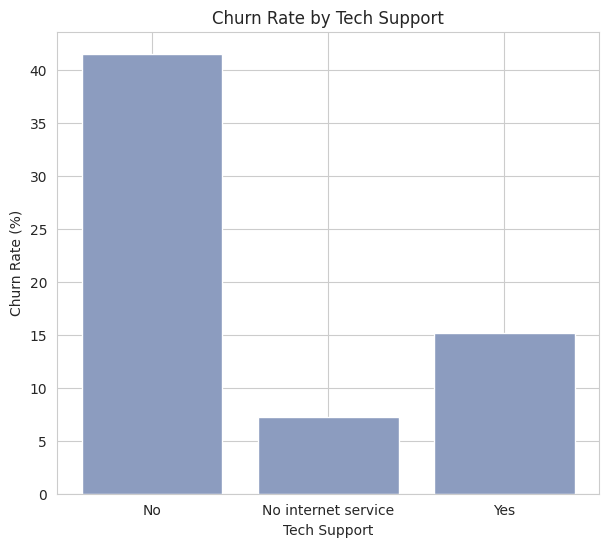

In [22]:
plt.figure(figsize=(7,6))
plt.bar(tech_support_churn.index,tech_support_churn.values,color="#8C9CBF")
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.show()

In [23]:
payment_churn_rate = (df.groupby("PaymentMethod")["Churn"].apply(lambda x: (x == "Yes").mean().round(3)* 100))
print(payment_churn_rate)

PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.1
Mailed check                 18.9
Name: Churn, dtype: float64


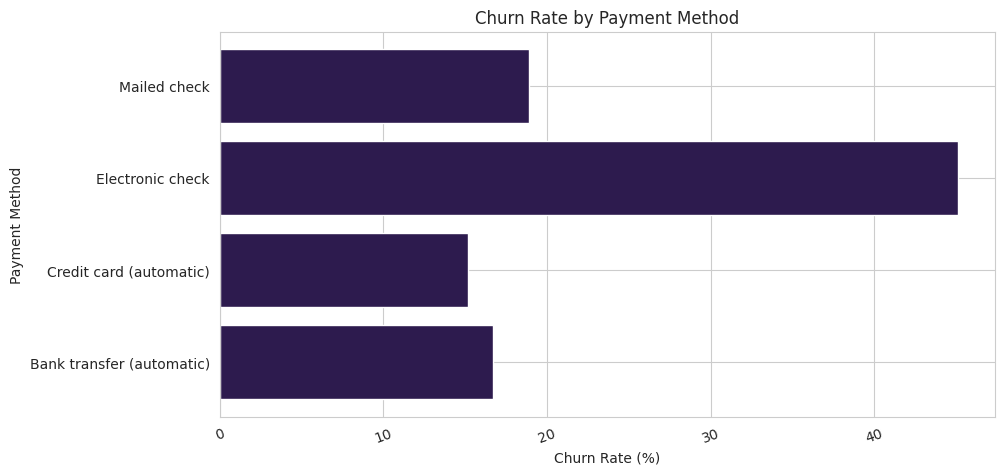

In [24]:
plt.figure(figsize=(10,5))
plt.barh(payment_churn_rate.index,payment_churn_rate.values ,color="#2D1B4E")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.xticks(rotation=20)
plt.show()

In [25]:
monthly_charges_churn = (df.groupby("Churn")["MonthlyCharges"].mean().round(1))
print(monthly_charges_churn)

Churn
No     61.3
Yes    74.6
Name: MonthlyCharges, dtype: float64


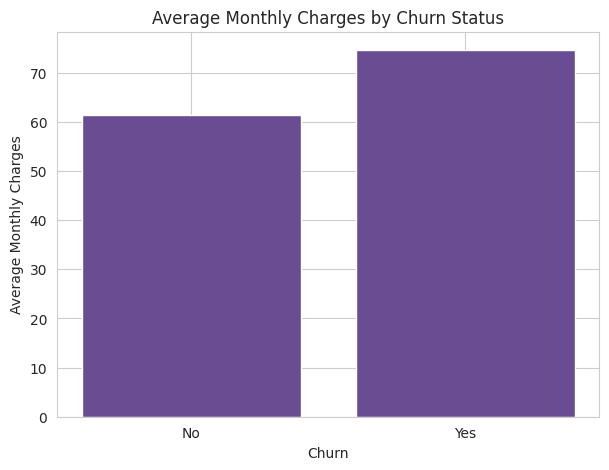

In [26]:
plt.figure(figsize=(7,5))
plt.bar(monthly_charges_churn.index,monthly_charges_churn.values ,color='#6A4C93')
plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.show()